# Week 3 - Sensitivity analysis

This exercise uses the same predator-prey model we used for the multi-model exercise, focusing on the Python version. As with the other exercise, define a model object for the function below, with the uncertainty ranges provided:

|Parameter	|Range or value	        |
|-----------|--------------:|
|prey_birth_rate    	|0.015 – 0.035	|
|predation_rate|0.0005 – 0.003 	|
|predator_efficiency     	|0.001 – 0.004	    |
|predator_loss_rate	    |0.04 – 0.08	    |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ema_workbench import (Model, RealParameter, TimeSeriesOutcome, perform_experiments, ema_logging)

from ema_workbench import Samplers

from ema_workbench.analysis import feature_scoring
from ema_workbench.analysis.scenario_discovery_util import RuleInductionType
from ema_workbench.em_framework.salib_samplers import get_SALib_problem
from SALib.analyze import sobol

In [2]:
def pred_prey(prey_birth_rate=0.025, predation_rate=0.0015, predator_efficiency=0.002,
             predator_loss_rate=0.06, initial_prey=50, initial_predators=20, dt=0.25,
             final_time=365, reps=1):

    #Initial values
    predators = np.zeros((reps, int(final_time/dt)+1))
    prey = np.zeros((reps, int(final_time/dt)+1))
    sim_time = np.zeros((reps, int(final_time/dt)+1))

    for r in range(reps):

        predators[r,0] = initial_predators
        prey[r,0] = initial_prey

    #Calculate the time series
    for t in range(0, sim_time.shape[1]-1):

        dx = (prey_birth_rate*prey[r,t]) - (predation_rate*prey[r,t]*predators[r,t])
        dy = (predator_efficiency*predators[r,t]*prey[r,t]) - (predator_loss_rate*predators[r,t])

        prey[r,t+1] = max(prey[r,t] + dx*dt, 0)
        predators[r,t+1] = max(predators[r,t] + dy*dt, 0)
        sim_time[r,t+1] = (t+1)*dt

    #Return outcomes
    return {'TIME':sim_time,
            'predators':predators,
            'prey':prey}

In [3]:
ema_logging.log_to_stderr(ema_logging.INFO)

uncertainties = [RealParameter('prey_birth_rate', 0.015, 0.035),
                 RealParameter('predation_rate', 0.0005, 0.003),
                 RealParameter('predator_efficiency', 0.001, 0.004),
                 RealParameter('predator_loss_rate', 0.04, 0.08)
                ]

outcomes = [TimeSeriesOutcome('TIME'),
            TimeSeriesOutcome('predators'),
            TimeSeriesOutcome('prey')]

In [4]:
py_model = Model('Python', function=pred_prey)
py_model.uncertainties = uncertainties
py_model.outcomes = outcomes

#### 1. Sensitivity analysis
Sensitivity analysis often focuses on the final values of an outcome at the end of the simulation. However, we can also look at metrics that give us additional information about the behavior of the model over time. Using [the statsmodel library](https://www.statsmodels.org/stable/index.html) and an appropriate sampling design, fit a linear regression model for each of the following indicators. What can we conclude about the behavior of the model, and about the importance of the different inputs?

  * The final values of the _prey_ outcome
  * The mean values of the _prey_ outcome over time, within each experiment
  * The standard deviations of the _prey_ outcome over time, within each experiment

In [5]:
no_experiments = 1000
results = perform_experiments(py_model, scenarios=no_experiments, uncertainty_sampling=Samplers.LHS)
experiments, outcomes = results

[MainProcess/INFO] performing 1000 scenarios * 1 policies * 1 model(s) = 1000 experiments
100%|█████████████████████████████████████| 1000/1000 [00:04<00:00, 241.84it/s]
[MainProcess/INFO] experiments finished


In [6]:
for k, v in outcomes.items():
    print(f"{k}: {np.array(v).shape}")

TIME: (1000, 1, 1461)
predators: (1000, 1, 1461)
prey: (1000, 1, 1461)


In [7]:
outcomes['predators'].shape

(1000, 1, 1461)

In [8]:
outcomes['prey']

array([[[50.        , 49.59567397, 49.19385902, ..., 82.90471707,
         82.72226112, 82.53276323]],

       [[50.        , 50.03245451, 50.05839321, ...,  4.26532037,
          4.28674658,  4.30831395]],

       [[50.        , 49.78352901, 49.54589889, ...,  0.59652919,
          0.59984022,  0.60318102]],

       ...,

       [[50.        , 50.11200213, 50.22332773, ..., 51.03438387,
         50.87231329, 50.70832222]],

       [[50.        , 49.89514912, 49.77889704, ...,  6.11231569,
          5.94256028,  5.7785183 ]],

       [[50.        , 49.85376205, 49.70690465, ..., 31.59320371,
         31.60641076, 31.62047498]]])

In [9]:
prey_final = outcomes['prey'][:,0,-1] # final prey value for each experiment (at the last time step, for the only replicate)
prey_final.shape

(1000,)

In [10]:
prey_mean = np.mean(outcomes['prey'][:,0,:],axis=1)
prey_std = np.std(outcomes['prey'][:,0,:],axis=1)

In [11]:
experiments

,predation_rate,predator_efficiency,predator_loss_rate,prey_birth_rate,scenario,policy,model
0,0.002529,0.001471,0.068698,0.018244,0,None,Python
1,0.001062,0.002886,0.045817,0.023828,1,None,Python
2,0.002360,0.003848,0.041905,0.029876,2,None,Python
3,0.000565,0.003492,0.070548,0.020990,3,None,Python
4,0.001933,0.003827,0.076773,0.027548,4,None,Python
...,...,...,...,...,...,...,...
995,0.000967,0.001380,0.077572,0.027402,995,None,Python
996,0.002030,0.002985,0.067131,0.024135,996,None,Python
997,0.000787,0.001610,0.061689,0.024702,997,None,Python
998,0.001375,0.003558,0.042405,0.019112,998,None,Python


## LINEAR MODEL

In [12]:
import statsmodels.api as sm
import pandas as pd

X = pd.DataFrame(experiments).drop(columns=['policy', 'model'], inplace=False, axis=1)
X_0 = sm.add_constant(X)

linear_model = sm.OLS(prey_final, X_0.astype(float)).fit()
linear_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     119.0
Date:                Sun, 25 May 2025   Prob (F-statistic):           1.08e-98
Time:                        15:25:04   Log-Likelihood:                -4198.2
No. Observations:                1000   AIC:                             8408.
Df Residuals:                     994   BIC:                             8438.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  43.5492      4.021     10.830      0.000      35.659      51.440
predation_rate       -154.1039    708.537     -0.217      0.828   -1544.503    1236.295
predator_efficiency  -1.37e+04    591.437    -23.170      0.000   -1.49e+04   -1.25e+04
predator_loss_rate    351.4634     44.299      7.934      0.000     264.533     438.394
prey_birth_rate      -109.1752     88.619     -1.232      0.218    -283.078      64.728
scenario                0.0015      0.002      0.847      0.397      -0.002       0.005
==============================================================================
Omnibus:                       93.269   Durbin-Watson:                   2.008
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              118.660
Skew:                           0.840   Prob(JB):                     1.71e-26
Kurtosis:                       3.168   Cond. No.                     8.00e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large,  8e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Only predator_efficiency and predator_loss_rate is statistically significant. R2 is only 0.38.

the linear regression clearly isn't capturing most of the output variance (as shown by the R2 value). We can therefore use the Sobol results with the SALib analysis functions for a more comprehensive analysis. We first use the get_SALib_problem to convert the uncertainties we have previously defined, to a dictionary which is compatible with SALib. This includes the names and bounds of the uncertainties.

#### 2. SOBOL
Use the Sobol sampling functionality included in the Workbench to perform experiments with a sample size of N=50, then analyze the results with SALib for the same three indicators. This requires specifying the keyword argument `'uncertainty_sampling'` of perform_experiments. Note that when using Sobol sampling, the meaning of the keyword argument `scenarios` changes a bit. In order to properly estimate Sobol scores as well as interaction effects, you require **N * (2D+2) scenarios**, where D is the number of uncertain parameters, and N is the value for scenarios passed to `perform_experiments`. Repeat the analysis for larger sample sizes, with N=250 and N=1000. How can we interpret the first-order and total indices? Are these sample sizes sufficient for a stable estimation of the indices? You'll need to use the [get_SALib_problem](https://emaworkbench.readthedocs.io/en/latest/ema_documentation/em_framework/salib_samplers.html) function to convert your Workbench experiments to a problem definition that you can pass to the SALib analysis function.

*hint*: sobol is a deterministic sequence of quasi random numbers. Thus, you can run with N=1000 and simply use slicing to get the results for N=50 and N=250.

It quantifies how much of the output variance is caused by each input (main effects) and by combinations of inputs (interaction effects).
In Sobol analysis, this is done by systematically varying inputs and measuring how much each one (and their combinations) contributes to the spread of the output.


In [13]:
problem = get_SALib_problem(uncertainties)
print(problem)

{'num_vars': 4, 'names': ['predation_rate', 'predator_efficiency', 'predator_loss_rate', 'prey_birth_rate'], 'bounds': [(0.0005, 0.003), (0.001, 0.004), (0.04, 0.08), (0.015, 0.035)]}


D=4 (4 uncertanties/problems).

By default, the Sobol sampler calculates second-order interaction effects between each pair of variables.

## N=50

In [ ]:
no_experiments = 50

experiments_sobol, outcomes_sobol = perform_experiments(py_model, scenarios=no_experiments,
                                                        uncertainty_sampling=Samplers.SOBOL)

/opt/anaconda3/envs/school/lib/python3.12/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
[MainProcess/INFO] performing 500 scenarios * 1 policies * 1 model(s) = 500 experiments


100%|███████████████████████████████████████| 500/500 [00:02<00:00, 197.94it/s]
[MainProcess/INFO] experiments finished


In [15]:
prey_final_sobol = outcomes_sobol['prey'][:,0,-1]
prey_mean_sobol = np.mean(outcomes_sobol['prey'][:,0,:],axis=1)
prey_std_sobol = np.std(outcomes_sobol['prey'][:,0,:],axis=1)

In [ ]:
Si = sobol.analyze(problem, prey_mean_sobol, calc_second_order=True, print_to_console=True)

                           ST   ST_conf
predation_rate       0.004609  0.003010
predator_efficiency  0.793403  0.296289
predator_loss_rate   0.172344  0.105462
prey_birth_rate      0.012768  0.007211
                           S1   S1_conf
predation_rate      -0.006491  0.022908
predator_efficiency  0.840192  0.416945
predator_loss_rate   0.167530  0.134356
prey_birth_rate     -0.018525  0.048500
                                                 S2   S2_conf
(predation_rate, predator_efficiency)      0.006977  0.050498
(predation_rate, predator_loss_rate)      -0.000193  0.041154
(predation_rate, prey_birth_rate)          0.014275  0.034841
(predator_efficiency, predator_loss_rate) -0.113912  0.713260
(predator_efficiency, prey_birth_rate)    -0.046706  0.694584
(predator_loss_rate, prey_birth_rate)      0.046803  0.245242


/opt/anaconda3/envs/school/lib/python3.12/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


- S1 (First-order index), S2 (Second-order index), ST (Total-order index)
- S1_conf (First-order index confidence interval), S2_conf (Second-order index confidence interval)
- predator_efficiency has ST = 0.79 → it explains ~79% of the variance (including interactions); predation_rate has ST = 0.006 → it has almost no effect.
- predator_efficiency S1 = 0.82 → most of its effect is direct, not through interactions; predation_rate S1 ≈ 0 → no main effect.
- The pair (predator_efficiency, prey_birth_rate) S2 = 0.23 → their interaction explains 23% of the variance

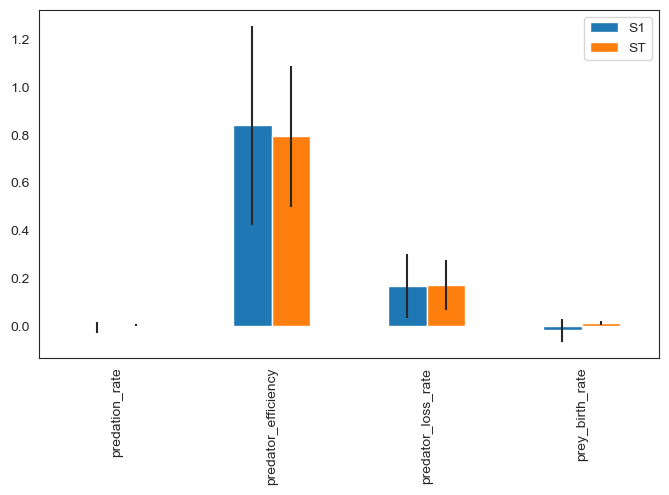

In [17]:
import seaborn as sns

Si_filter = {k: Si[k] for k in ['ST', 'ST_conf', 'S1', 'S1_conf']}
Si_df = pd.DataFrame(Si_filter, index=problem['names'])

sns.set_style('white')
fig, ax = plt.subplots(1)

indices = Si_df[['S1','ST']]
err = Si_df[['S1_conf','ST_conf']] # confidence intervals for the indices

indices.plot.bar(yerr=err.values.T,ax=ax)
fig.set_size_inches(8,6)
fig.subplots_adjust(bottom=0.3)
plt.show()

## N = 250

In [18]:
experiments_sobol250, outcomes_sobol250 = perform_experiments(py_model, scenarios=250,
                                                        uncertainty_sampling=Samplers.SOBOL)

/opt/anaconda3/envs/school/lib/python3.12/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
[MainProcess/INFO] performing 2500 scenarios * 1 policies * 1 model(s) = 2500 experiments
100%|█████████████████████████████████████| 2500/2500 [00:10<00:00, 235.53it/s]
[MainProcess/INFO] experiments finished


In [19]:
prey_final_sobol250 = outcomes_sobol250['prey'][:,0,-1]
prey_mean_sobol250 = np.mean(outcomes_sobol250['prey'][:,0,:],axis=1)
prey_std_sobol250 = np.std(outcomes_sobol250['prey'][:,0,:],axis=1)

In [20]:
Si = sobol.analyze(problem, prey_mean_sobol250, calc_second_order=True, print_to_console=True)

                           ST   ST_conf
predation_rate       0.004943  0.001544
predator_efficiency  0.800376  0.137313
predator_loss_rate   0.214858  0.046651
prey_birth_rate      0.011333  0.002882
                           S1   S1_conf
predation_rate       0.000569  0.009609
predator_efficiency  0.783195  0.152353
predator_loss_rate   0.167803  0.073008
prey_birth_rate     -0.008880  0.022347
                                                 S2   S2_conf
(predation_rate, predator_efficiency)      0.003899  0.024719
(predation_rate, predator_loss_rate)       0.008329  0.014148
(predation_rate, prey_birth_rate)          0.011578  0.012851
(predator_efficiency, predator_loss_rate)  0.025793  0.327200
(predator_efficiency, prey_birth_rate)     0.006971  0.254987
(predator_loss_rate, prey_birth_rate)      0.040413  0.105868


/opt/anaconda3/envs/school/lib/python3.12/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


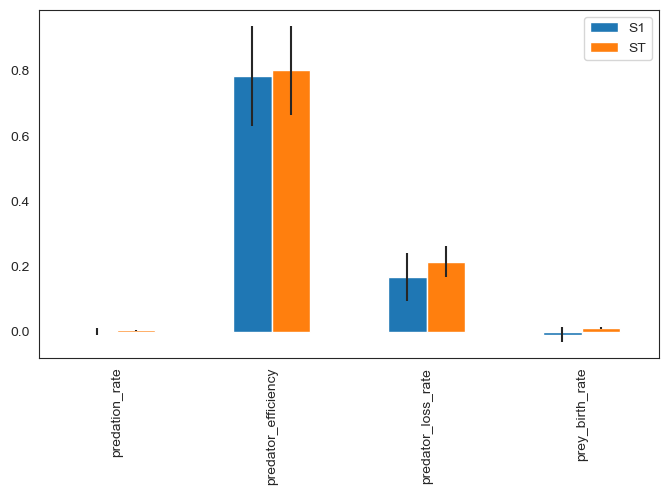

In [21]:
Si_filter = {k: Si[k] for k in ['ST', 'ST_conf', 'S1', 'S1_conf']}
Si_df = pd.DataFrame(Si_filter, index=problem['names'])

sns.set_style('white')
fig, ax = plt.subplots(1)

indices = Si_df[['S1','ST']]
err = Si_df[['S1_conf','ST_conf']] # confidence intervals for the indices

indices.plot.bar(yerr=err.values.T,ax=ax)
fig.set_size_inches(8,6)
fig.subplots_adjust(bottom=0.3)
plt.show()

Bigger N -> smaller confidence (more precise)

In [24]:
Y = prey_mean_sobol250

s_data = pd.DataFrame(index=problem['names'],
                      columns=np.arange(20, 250 # no_experiments
                                        , 50)*(2*problem['num_vars']+2))
for j in s_data.columns:
    scores = sobol.analyze(problem, Y[0:j], calc_second_order=True, print_to_console=False)
    s_data.loc[:,j] = scores['ST']

/opt/anaconda3/envs/school/lib/python3.12/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


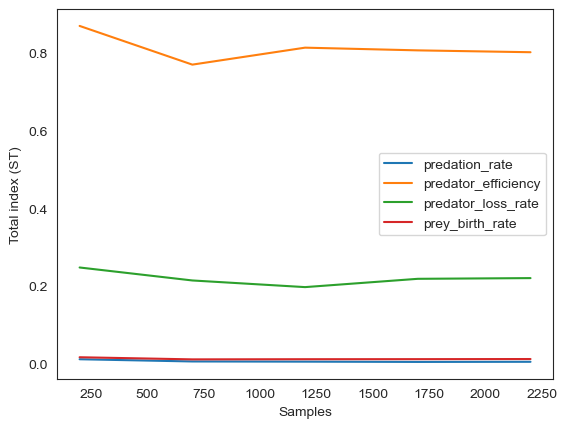

In [27]:
fig, ax = plt.subplots(1)

s_data.T.plot(ax=ax)
ax.set_xlabel('Samples')
ax.set_ylabel('Total index (ST)')
plt.show()

The figure shows the estimate of the total order effect for all parameters as a function of the number of samples. The estimates converge relatively quickly because they become essentially stable after 700 samples.

#### 3. Extra trees
Use the [Extra-Trees analysis](https://emaworkbench.readthedocs.io/en/latest/ema_documentation/analysis/feature_scoring.html) included in the Workbench to approximate the Sobol total indices, with a suitable sampling design. As a starting point, use an ensemble of **100 trees** and a **max_features parameter of 0.6**, and set the analysis to **regression mode**. Are the estimated importances stable relative to the sample size and the analysis parameters? How do the results compare to the Sobol indices? For more details on this analysis see [Jaxa-Rozen & Kwakkel (2018)](https://www.sciencedirect.com/science/article/pii/S1364815217311581)

Extra-Trees measure how much each input parameter helps reduce prediction error across all trees.
The more a parameter splits the data and reduces error, the higher its feature importance score.

In [28]:
from ema_workbench.analysis import feature_scoring

The Extra-Trees analysis is performed to approximate the Sobol total indices. The analysis aims to assess the importance of input parameters on the model output, considering their interactions. The Extra-Trees method is an efficient alternative to the more computationally expensive Sobol indices.

In [29]:
scores = feature_scoring.get_ex_feature_scores(experiments_sobol250, prey_final_sobol250,
                                               max_features=0.6, mode=RuleInductionType.REGRESSION)[0]
scores

,1
0,
predator_efficiency,0.516073
predator_loss_rate,0.227008
prey_birth_rate,0.186149
predation_rate,0.070771


These scores are analogous to the Sobol total-order indices (ST). predator_efficiency is the most important parameter (explains ~52% of the variance).

In [ ]:
combined_scores = []
for j in range(100, experiments_sobol250.shape[0], 100):
    scores = feature_scoring.get_ex_feature_scores(experiments_sobol250.iloc[0:j, :],
                                                   prey_mean_sobol250[0:j],
                                                   max_features=0.6,
                                                   mode=RuleInductionType.REGRESSION)[0]
    scores.columns = [j]
    combined_scores.append(scores)

In [32]:
combined_scores = pd.concat(combined_scores, axis=1, sort=True)

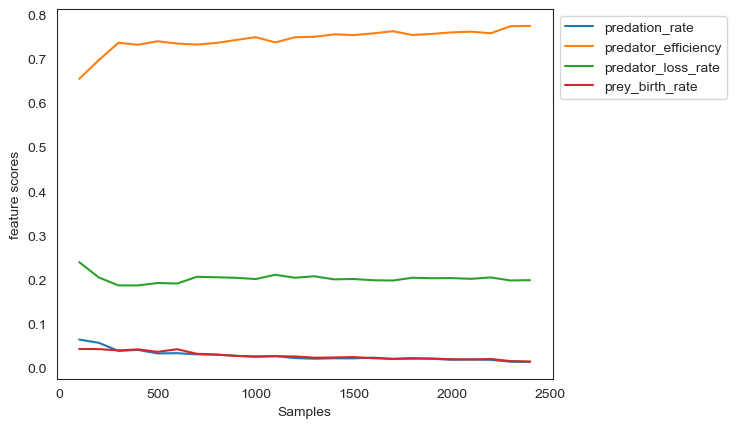

In [33]:
fig, ax = plt.subplots(1)

combined_scores.T.plot(ax=ax)
ax.legend(bbox_to_anchor=(1,1))
ax.set_xlabel('Samples')
ax.set_ylabel('feature scores')
plt.show()

Similar convergence?
If the ranking of important parameters is similar, both methods are supporting each other. If not, it may be worth investigating model structure, sample size, or parameter settings.

In [34]:
combined_scores

,100,200,300,400,500,600,700,800,900,1000,...,1500,1600,1700,1800,1900,2000,2100,2200,2300,2400
0,,,,,,,,,,,,,,,,,,,,,
predation_rate,0.063736,0.056444,0.038149,0.040291,0.032387,0.032939,0.030315,0.029439,0.026991,0.024628,...,0.021177,0.022830,0.019959,0.021961,0.020217,0.017952,0.018620,0.017794,0.013519,0.013119
predator_efficiency,0.654564,0.696823,0.736213,0.731692,0.739671,0.734377,0.732143,0.735810,0.742502,0.748878,...,0.753668,0.757504,0.762411,0.753801,0.756305,0.759770,0.761330,0.757837,0.773783,0.774387
predator_loss_rate,0.239307,0.204511,0.186486,0.186408,0.191964,0.190774,0.205946,0.204932,0.203740,0.200882,...,0.201009,0.198157,0.197553,0.203814,0.202739,0.203022,0.201405,0.204539,0.197647,0.198335
prey_birth_rate,0.042394,0.042222,0.039151,0.041608,0.035978,0.041910,0.031596,0.029819,0.026766,0.025612,...,0.024145,0.021509,0.020077,0.020424,0.020739,0.019255,0.018645,0.019829,0.015050,0.014159
